In [ ]:
# Joker Lottery Data Analysis
# This notebook analyzes the Joker lottery draw data from `Joker.csv`.
# These are real draw numbers.

# Load required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Load the Joker dataset
csv_path = r"c:\Dev\Python\Datasets\Joker.csv"
df = pd.read_csv(csv_path)

df.head()

,Date,Draw_num,num_1,num_2,num_3,num_4,num_5,num_joker
0,08-01-26,3012,43,26,3,15,17,7
1,11-01-26,3013,28,35,7,22,41,18
2,13-01-26,3014,10,8,28,13,18,7
3,15-01-26,3015,7,6,31,39,36,1
4,18-01-26,3016,17,13,28,42,29,2


In [2]:
## Inspect Dataset Structure
#  Display the first rows, summary statistics, and data types to understand the dataset.

# Preview the data
print("Dataset shape:", df.shape, "\n")
df.head()

Dataset shape: (67, 8) 



,Date,Draw_num,num_1,num_2,num_3,num_4,num_5,num_joker
0,08-01-26,3012,43,26,3,15,17,7
1,11-01-26,3013,28,35,7,22,41,18
2,13-01-26,3014,10,8,28,13,18,7
3,15-01-26,3015,7,6,31,39,36,1
4,18-01-26,3016,17,13,28,42,29,2


In [3]:
# Summary statistics for numeric columns
df.describe()

,Draw_num,num_1,num_2,num_3,num_4,num_5,num_joker
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,3045.000000,18.761194,20.492537,21.955224,26.820896,27.164179,9.880597
std,19.485037,14.296736,13.649701,12.803211,11.102723,12.845937,5.650214
min,3012.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000
25%,3028.500000,5.000000,8.000000,9.000000,18.500000,18.000000,6.000000
50%,3045.000000,17.000000,18.000000,22.000000,26.000000,30.000000,10.000000
75%,3061.500000,30.500000,30.000000,33.000000,37.000000,38.500000,14.500000
max,3078.000000,45.000000,45.000000,44.000000,43.000000,45.000000,20.000000


In [4]:
# Data types and missing values
info = df.dtypes.to_frame(name="dtype")
info["missing"] = df.isna().sum()

info

,dtype,missing
Date,str,0
Draw_num,int64,0
num_1,int64,0
num_2,int64,0
num_3,int64,0
num_4,int64,0
num_5,int64,0
num_joker,int64,0


In [ ]:
## Clean and Preprocess Data
#  Convert the `Date` column to datetime, verify numeric columns, and handle any missing values.

# Convert Date column to datetime
# If error occurs during conversion, it will be coerced to NaT (Not a Time)
# instead of raising an exception.
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%y", errors="coerce")

# Ensure numeric columns are numeric
numeric_columns = ["num_1", "num_2", "num_3", "num_4", "num_5", "num_joker"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check for missing values after type conversion
missing_after_clean = df[numeric_columns + ["Date"]].isna().sum()

# Display cleaned info
print(f"Missing values after cleaning:\n{missing_after_clean}")
print("\nDate range:", df["Date"].min(), "to", df["Date"].max())

Missing values after cleaning:
num_1        0
num_2        0
num_3        0
num_4        0
num_5        0
num_joker    0
Date         0
dtype: int64

Date range: 2023-04-19 00:00:00 to 2026-06-11 00:00:00


In [6]:
## Analyze Main Number Frequencies
#  Compute the frequency of each main number across `num_1` to `num_5`
#  and identify the most common values.

# Combine main number columns into a single series for frequency analysis
main_numbers = pd.melt(df, value_vars=["num_1", "num_2", "num_3", "num_4", "num_5"], value_name="main_number")
main_frequencies = main_numbers["main_number"].value_counts().sort_index()

# Top main numbers
top_main_numbers = main_frequencies.sort_values(ascending=False).head(10)

main_frequencies.head(20), top_main_numbers

(main_number
 1      4
 2     15
 3      8
 4      9
 5      5
 6     10
 7      8
 8     10
 9      7
 10     4
 11     4
 12    10
 13     9
 14     2
 15     8
 16     4
 17     5
 18    14
 19     4
 20     5
 Name: count, dtype: int64,
 main_number
 2     15
 18    14
 28    12
 38    11
 8     10
 26    10
 12    10
 44    10
 41    10
 6     10
 Name: count, dtype: int64)

In [ ]:
## Analyze Joker Number Frequency
#  Compute frequency counts for the Joker number and compare its distribution to the main numbers.

joker_frequency = df["num_joker"].value_counts().sort_index()


joker_frequency.head(20)

num_joker
1     5
2     3
3     3
4     2
5     3
6     5
7     7
8     3
9     2
10    4
11    3
12    4
13    3
14    3
15    1
16    4
17    4
18    5
19    1
20    2
Name: count, dtype: int64

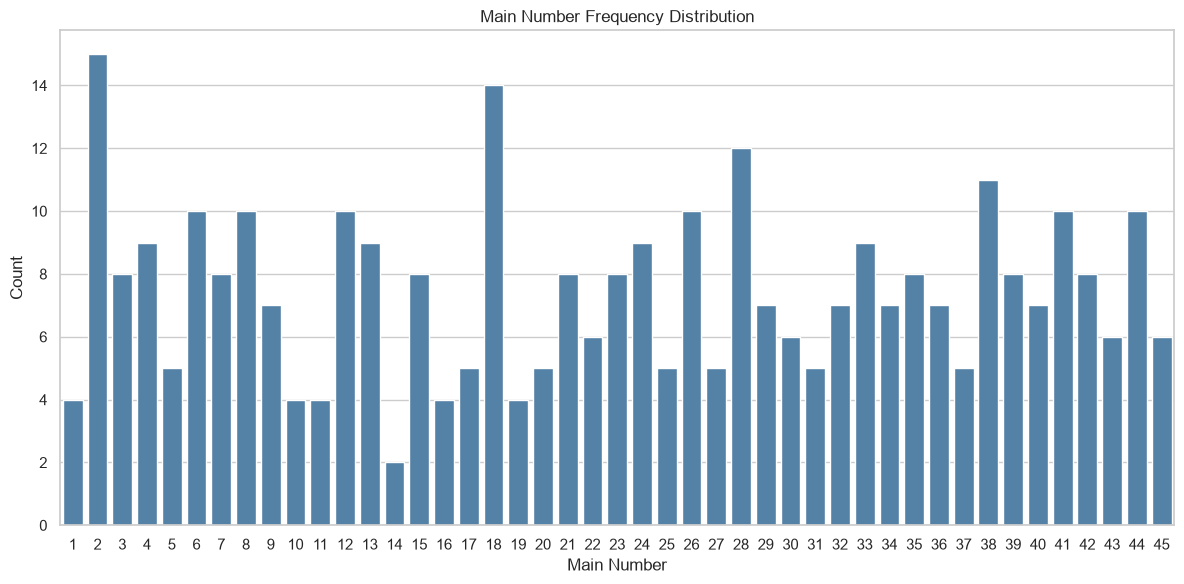

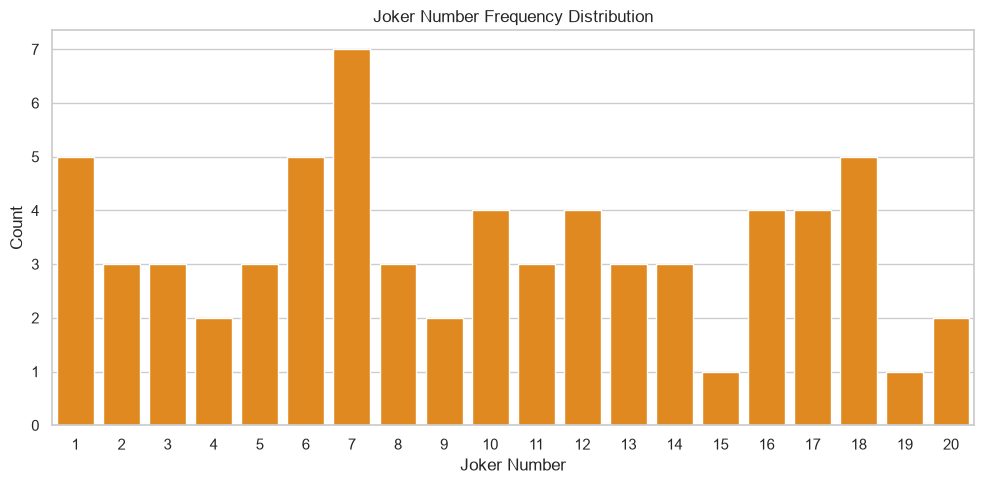

In [8]:
## Visualize Number Distributions
#  Create plots for main number and Joker number distributions using matplotlib and seaborn.

# Plot main number frequency distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=main_frequencies.index, y=main_frequencies.values, color="steelblue")
plt.title("Main Number Frequency Distribution")
plt.xlabel("Main Number")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot Joker number frequency distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=joker_frequency.index, y=joker_frequency.values, color="darkorange")
plt.title("Joker Number Frequency Distribution")
plt.xlabel("Joker Number")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Summary
# - Loaded the Joker dataset and inspected its structure.
# - Cleaned the `Date` column and verified numeric fields.
# - Computed frequency distributions for main numbers and Joker numbers.
# - Visualized the number distributions for quick insight.